<h1>M3: Model & Evaluation</h1>

<h3>Import Libaries</h3>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score

### 1. Define the modeling task
##### Outcome Being Modeled
The outcome (target) variable is **`ev_adpotion_rate`**.
This represents the proportion of residents in each ZIP code who own an electric vehicle (BEV or PHEV).  Using adoption rate instead of raw EV count allows fair comparison across ZIP codes with different population sizes.
#### Type of Prediction
This is a *supervised regression problem*.The model aims to estimate how median household income, population size, and median age influence EV adoption rates across zip codes in Washington State.
I choose the Supervised because the dataset contains labeled outcomes (observed EV adoption rates)and first model is Linear Regression because the target variable (adoption rate) is continuous.

In [2]:
# Load data
df = pd.read_csv("m2output.csv")

# Recalculate the ev_adoption_rate cleanly
df = df.drop(columns=["ev_adoption_rate"])

# Group by ZIP-level and sum ev_count
df = df.groupby(
    ["zip_code", "county", "city", "median_income_household", "population", "median_age"],
    as_index=False
)["ev_count"].sum()

# Re-create EV adoption rate
df["population"] = pd.to_numeric(df["population"], errors="coerce")
df = df[df["population"] > 0].copy()
df["ev_adoption_rate"] = df["ev_count"] / df["population"]

df = df.dropna(subset=["ev_adoption_rate", "median_income_household", "population", "median_age", "zip_code"])
df.head()

,zip_code,county,city,median_income_household,population,median_age,ev_count,ev_adoption_rate
0,98001,King,Auburn,107218,36041,39.9,1207,0.033490
1,98002,King,Auburn,77714,37284,35.6,492,0.013196
2,98003,King,Federal Way,70800,52210,36.4,965,0.018483
3,98004,King,Bellevue,176367,39435,38.4,4003,0.101509
4,98005,King,Bellevue,158396,21929,37.3,2039,0.092982


In [3]:
# Target and features
y = df["ev_adoption_rate"]

X = df[[
    "median_income_household",
    "population",
    "median_age",
    "zip_code"
]]

# Replace inf/-inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)


X.head()

,median_income_household,population,median_age,zip_code
0,107218,36041,39.9,98001
1,77714,37284,35.6,98002
2,70800,52210,36.4,98003
3,176367,39435,38.4,98004
4,158396,21929,37.3,98005


### 2.Train a baseline model

In [4]:
# Identify categorical and numeric columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['median_income_household', 'population', 'median_age', 'zip_code']
Categorical columns: []


In [5]:
# Preprocess: impute + encode
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [6]:
#Single train-test split used for BOTH models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Create pipeline with Linear Regression
baseline_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

#### Model Selection

A **Linear Regression** model is used as the baseline model.

Linear Regression is simple and interpretable.  
It helps quantify how median income, population size, and median age are associated with EV adoption rates.

###### Features Used

- Median household income  
- Population size  
- Median age
- Zip Code

These variables directly match the research question.

In [8]:
# Fit baseline model + predict
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)


#### Evaluation Metrics
The following regression metrics are used:

- *MAE (Mean Absolute Error)* Average absolute prediction error  
- *RMSE (Root Mean Squared Error)*  Penalizes large errors more  
- *R² (Coefficient of Determination)*  Measures how well the model explains variance  

Lower MAE and RMSE are better.  
Higher R² (closer to 1) is better.

In [9]:
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)

print("Baseline Model: Linear Regression")
print("MAE :", round(mae_lr, 4))
print("RMSE:", round(rmse_lr, 4))
print("R²  :", round(r2_lr, 3))



Baseline Model: Linear Regression
MAE : 0.0181
RMSE: 0.0267
R²  : 0.236


- The MAE of 0.0181 means the model’s average prediction error is about 1.8 percentage points in EV adoption rate.

- The RMSE of 0.0267 shows that some larger prediction errors occur, but overall the deviations are still relatively small.

- The R² value of 0.236 indicates that 23.6% of the variation in EV adoption rates across ZIP codes is explained by income, population, and median age.

### 3. Train an improved model

#### Model Selection
To improve predictive performance, a *Random Forest Regressor* is used.

Random Forest is an ensemble learning method that:
- Captures non-linear relationships
- Handles interaction effects between variables
- Is more flexible than Linear Regression

Because EV adoption patterns may not follow a simple linear trend, a Random Forest model is expected to perform better.

In [10]:
# Improved model pipeline
rf_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

# Train RF on the SAME X_train, y_train split as baseline
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

#### Evaluation Metrics
The same regression metrics are used for fair comparison:
- *MAE (Mean Absolute Error)*
- *RMSE (Root Mean Squared Error)*
- *R² (Coefficient of Determination)*

In [12]:
# Evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Improved Model: Random Forest")
print("MAE :", round(mae_rf, 4))
print("RMSE:", round(rmse_rf, 4))
print("R²  :", round(r2_rf, 3))


Improved Model: Random Forest
MAE : 0.0213
RMSE: 0.052
R²  : -1.883


- The MAE of 0.0213 means the model’s predictions differ from the actual EV adoption rate by about 2.1 percentage points on average.

- The RMSE of 0.052 indicates that larger prediction errors still occur in some cases.

- The R² value of -1.883 shows that the model performs worse than simply predicting the average EV adoption rate for all ZIP codes.

Overall, the Random Forest model does not improve performance compared to Linear Regression. In this case, the simpler Linear Regression model performs better for predicting EV adoption rates.

### 4.Compare models

| Model | MAE | RMSE | R² |
|-------|------|------|------|
| Linear Regression | 0.0181 | 0.0267 | 0.236 |
| Random Forest | 0.0213 |0.052| -1.883 |


Both models have similar MAE values, but the Random Forest model has a higher RMSE (0.052) compared to Linear Regression (0.0267), indicating larger prediction errors. In addition, the Random Forest model has a negative R² value (-1.883), meaning it performs worse than simply predicting the average adoption rate. The Linear Regression model performs better, with a positive R² of 0.236, although the overall explanatory power is still modest.

#### Cross Validation

In [23]:
cv_scores_lr = cross_val_score(baseline_model, X, y, cv=5, scoring="r2")
print("Linear Regression — Cross-Validated R² per fold:", np.round(cv_scores_lr, 3))
print("Mean R²:", round(cv_scores_lr.mean(), 3))
print("Std  R²:", round(cv_scores_lr.std(), 3))

Linear Regression — Cross-Validated R² per fold: [-0.074 -0.251  0.012  0.198 -6.945]
Mean R²: -1.412
Std  R²: 2.77


In [25]:
# 5-fold cross-validation for Random Forest
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring="r2")
print("Random Forest — Cross-Validated R² per fold:", np.round(cv_scores_rf, 3))
print("Mean R²:", round(cv_scores_rf.mean(), 3))
print("Std  R²:", round(cv_scores_rf.std(), 3))

Random Forest — Cross-Validated R² per fold: [-0.063 -1.223  0.055 -1.841 -9.193]
Mean R²: -2.453
Std  R²: 3.444


##### Cross-Validation R² Comparison

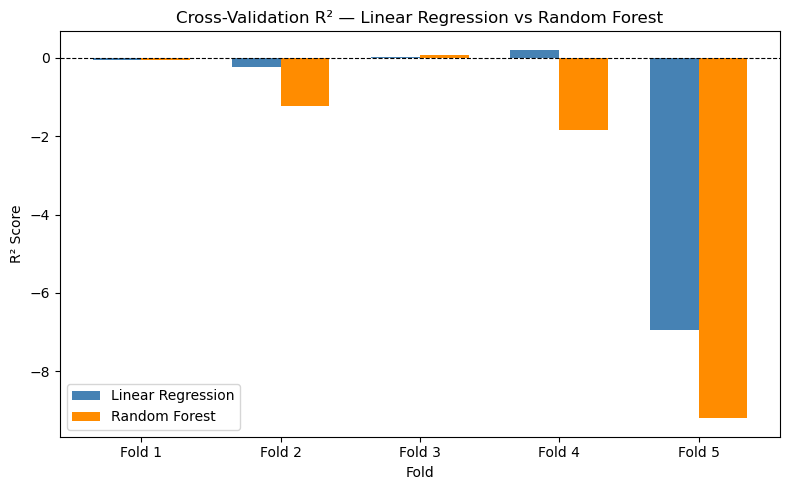

In [26]:
# Plot: Cross-Validation R² Comparison
fig, ax = plt.subplots(figsize=(8, 5))
folds = [f"Fold {i+1}" for i in range(5)]
x = np.arange(len(folds))
width = 0.35

bars1 = ax.bar(x - width/2, cv_scores_lr, width, label="Linear Regression", color="steelblue")
bars2 = ax.bar(x + width/2, cv_scores_rf, width, label="Random Forest", color="darkorange")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Fold")
ax.set_ylabel("R² Score")
ax.set_title("Cross-Validation R² — Linear Regression vs Random Forest")
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.legend()
plt.tight_layout()
plt.show()


Cross-validation confirms which model generalizes better across different data splits.A consistent R² across folds indicates a stable model.
High variance between folds may indicate overfitting or data imbalance. 
Linear Regression outperforms Random Forest overall, achieving a more stable R² across most folds, while Random Forest produces severely negative R² values especially in Fold 5, indicating it overfits the training data and fails to generalize. Both models struggle with consistency due to outlier ZIP codes and missing explanatory variables such as charging infrastructure and housing type. Given these results, Linear Regression remains the more reliable model for this dataset, though its low overall R² confirms that income, population, and median age alone are insufficient to fully explain EV adoption patterns across Washington State.

##### Feature importance for Linear Regression using coefficients

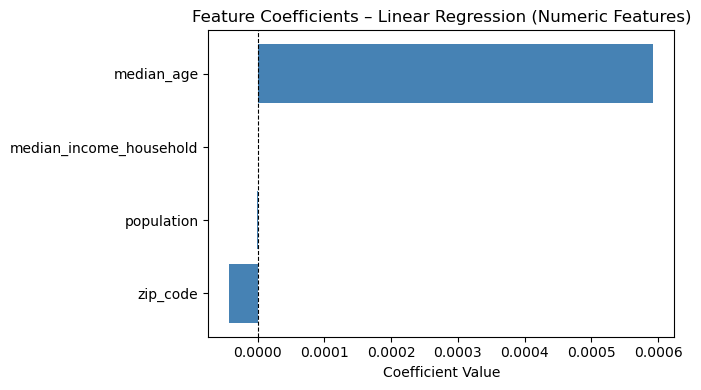

                Feature   Coefficient
             median_age  5.923729e-04
median_income_household  1.980903e-07
             population -1.805442e-07
               zip_code -4.220761e-05


In [30]:
lr_coefficients = baseline_model.named_steps["model"].coef_[:len(numeric_cols)]

lr_importance_df = pd.DataFrame({
    "Feature": numeric_cols,
    "Coefficient": lr_coefficients
}).sort_values("Coefficient", ascending=True)

# Plot
plt.figure(figsize=(7, 4))
plt.barh(lr_importance_df["Feature"], lr_importance_df["Coefficient"], color="steelblue")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Coefficient Value")
plt.title("Feature Coefficients – Linear Regression (Numeric Features)")
plt.tight_layout()
plt.show()

print(lr_importance_df.sort_values("Coefficient", ascending=False).to_string(index=False))

##### Feature Importance (Random Forest)

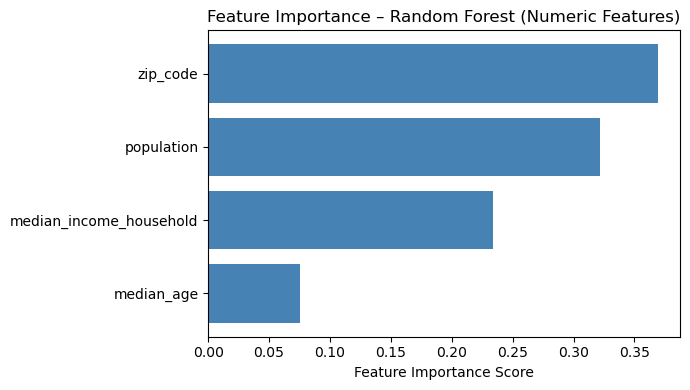

                Feature  Importance
               zip_code    0.368976
             population    0.321792
median_income_household    0.233588
             median_age    0.075644


In [28]:
# Extract numeric feature importances from Random Forest
rf_importances = rf_model.named_steps["model"].feature_importances_

# Only use numeric feature names (zip_code is categorical/encoded, so we show numeric only here)
numeric_importance_df = pd.DataFrame({
    "Feature": numeric_cols,
    "Importance": rf_importances[:len(numeric_cols)]
}).sort_values("Importance", ascending=True)

# Plot
plt.figure(figsize=(7, 4))
plt.barh(numeric_importance_df["Feature"], numeric_importance_df["Importance"], color="steelblue")
plt.xlabel("Feature Importance Score")
plt.title("Feature Importance – Random Forest (Numeric Features)")
plt.tight_layout()
plt.show()

print(numeric_importance_df.sort_values("Importance", ascending=False).to_string(index=False))


Linear Regression finds median_age as the strongest positive predictor, while median_income_household and population have near-zero coefficients, suggesting they contribute very little in a linear relationship. Random Forest tells a different story — zip_code (37%) and population (32%) dominate, with median_income_household (23%) as third, meaning location and size matter more than income when non-linear patterns are captured. The two models disagree on which features matter most, which further confirms that EV adoption has a complex, non-linear relationship with these variables that neither model fully captures with the current feature set.

##### Conclusion
Based on all the evidence, Linear Regression is the better model for this dataset.
Despite both models performing poorly overall, Linear Regression is more stable and interpretable — it achieves a positive R² (0.236) on the test set, while Random Forest produces a negative R² (-1.883), meaning Random Forest performs worse than simply predicting the average adoption rate. Cross-validation confirms this instability, with both models collapsing in Fold 5, but Random Forest showing more extreme negative scores across multiple folds. Therefore, Linear Regression is selected as the final model, not because it performs well in absolute terms, but because it is more consistent and trustworthy given the current features. The low R² across both models clearly indicates that median income, population, and median age alone are insufficient predictors — future work should incorporate additional variables such as charging infrastructure availability, housing type, and local EV incentive policies to build a more reliable and equitable predictive model for EV adoption across Washington State.

### 5. Evaluate with visuals

#### Actual vs Predicted Plot

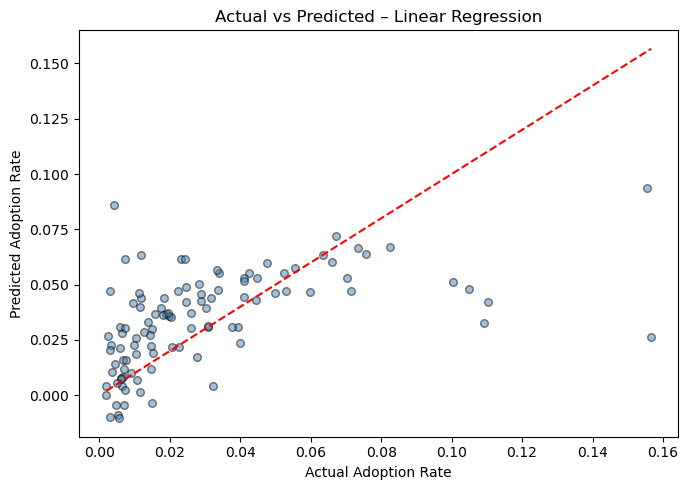

In [14]:
# Use Linear Regression predictions
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue", edgecolors="black", s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color="red", linewidth=1.5, linestyle="--")
plt.xlabel("Actual Adoption Rate")
plt.ylabel("Predicted Adoption Rate")
plt.title("Actual vs Predicted – Linear Regression")
plt.tight_layout()
plt.show()


The points are somewhat scattered around the diagonal line, indicating moderate predictive accuracy.The spread of points suggests that the model captures some general trends, but there is still substantial unexplained variation in EV adoption rates.

#### Residuals vs Predicted

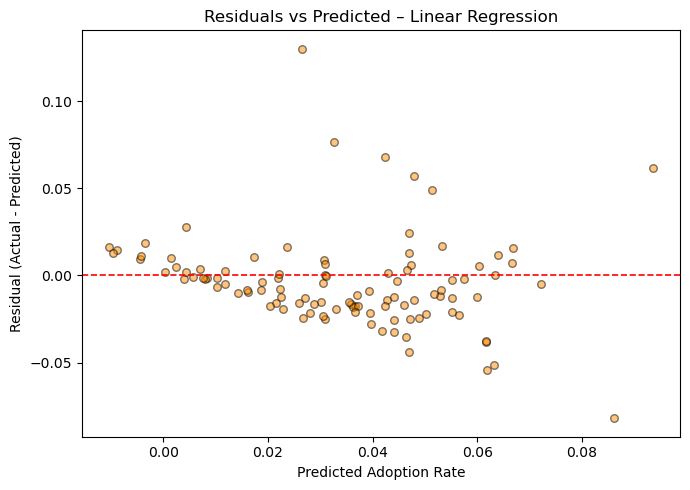

In [15]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color="darkorange", edgecolors="black", s=30)
plt.axhline(0, color="red", linewidth=1.2, linestyle="--")
plt.xlabel("Predicted Adoption Rate")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted – Linear Regression")
plt.tight_layout()
plt.show()


Residuals are distributed around zero, but there is noticeable spread. This indicates that while the model does not show strong systematic bias, it does not fully explain variability in EV adoption rates.

#### Residual Distribution

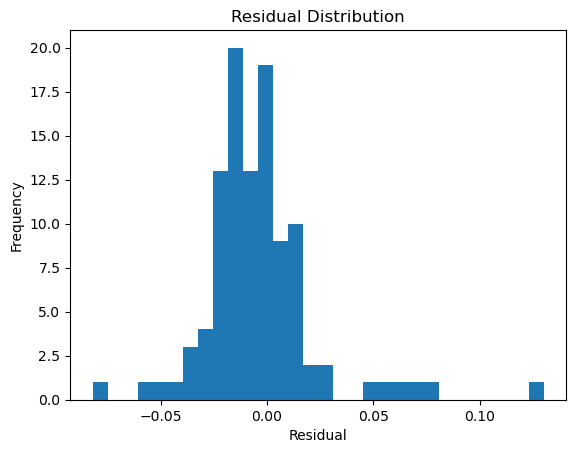

In [13]:
plt.figure()
plt.hist(residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

The residuals are centered around zero, suggesting that over- and under-predictions are balanced.However, the distribution shows variability, confirming that additional factors beyond income, population, and median age influence EV adoption.

#### Geographic Summary by County

In [16]:
# County-level summary
county_summary = (
    df.groupby("county")
    .agg(
        mean_adoption_rate=("ev_adoption_rate", "mean"),
        total_ev_count=("ev_count", "sum"),
        total_population=("population", "sum"),
        zip_code_count=("zip_code", "nunique")
    )
    .reset_index()
    .sort_values("mean_adoption_rate", ascending=False)
)

county_summary["mean_adoption_rate"] = county_summary["mean_adoption_rate"].round(4)
print(county_summary.to_string(index=False))


      county  mean_adoption_rate  total_ev_count  total_population  zip_code_count
        King              0.0768          132003           2175162              77
    San Juan              0.0721            1264             17960               8
Grays Harbor              0.0710            1000             71129              15
      Island              0.0500            3015             84569               7
    Kittitas              0.0450            1055             44696              10
   Snohomish              0.0396           33524            801727              24
   Jefferson              0.0395            1440             32026               7
       Mason              0.0356            1396             65451               9
       Clark              0.0336           17304            523538              19
      Kitsap              0.0328            9674            287607              19
      Pierce              0.0309           21703            892964              51
    

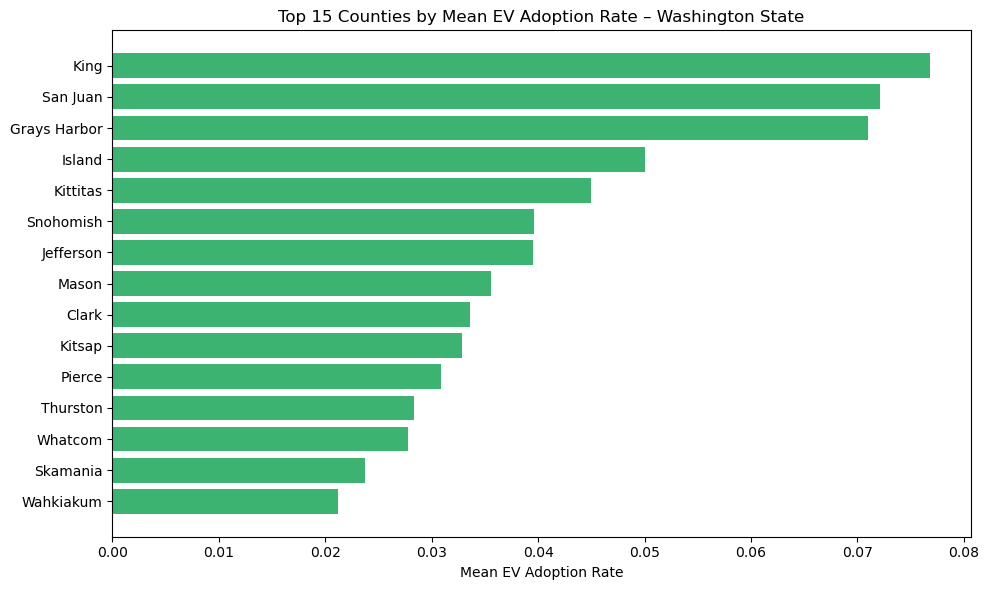

In [17]:
# Plot: Top 15 counties by mean EV adoption rate
top15 = county_summary.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top15["county"][::-1], top15["mean_adoption_rate"][::-1], color="mediumseagreen")
plt.xlabel("Mean EV Adoption Rate")
plt.title("Top 15 Counties by Mean EV Adoption Rate – Washington State")
plt.tight_layout()
plt.show()

King County leads with the highest EV adoption rate (7.68%), driven by its large wealthy urban population, while western coastal counties like San Juan and Grays Harbor also show surprisingly high rates despite small populations. Eastern and rural counties such as Franklin, Yakima, and Pend Oreille show the lowest adoption rates (under 1%), suggesting that geography, income, and infrastructure access create a clear west-east divide in EV adoption across Washington State.

##### Plot: Mean income vs mean adoption rate by county (scatter)

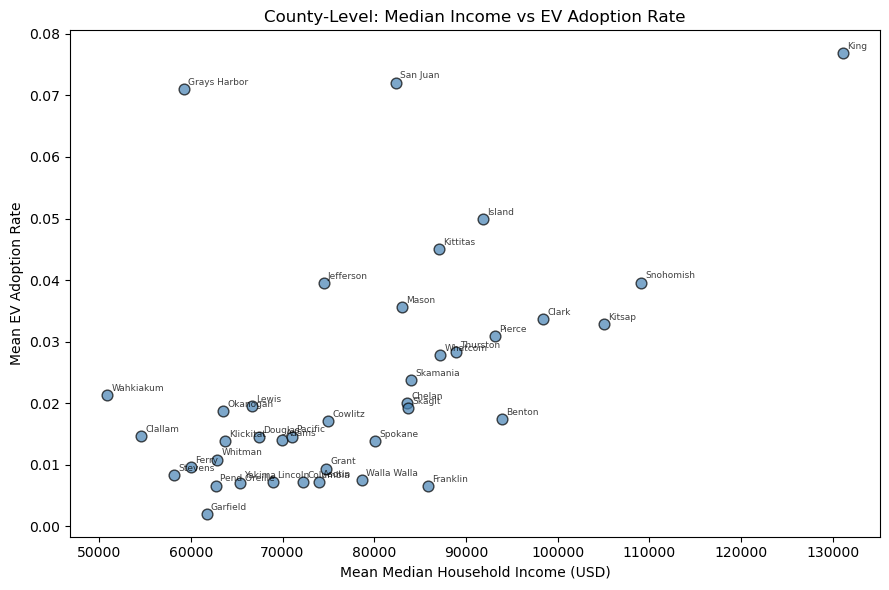

In [18]:

county_income = (
    df.groupby("county")
    .agg(
        mean_adoption_rate=("ev_adoption_rate", "mean"),
        mean_income=("median_income_household", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(9, 6))
plt.scatter(county_income["mean_income"], county_income["mean_adoption_rate"],
            color="steelblue", edgecolors="black", alpha=0.7, s=60)

for _, row in county_income.iterrows():
    plt.annotate(row["county"],
                 (row["mean_income"], row["mean_adoption_rate"]),
                 fontsize=6.5, alpha=0.75,
                 xytext=(3, 3), textcoords="offset points")

plt.xlabel("Mean Median Household Income (USD)")
plt.ylabel("Mean EV Adoption Rate")
plt.title("County-Level: Median Income vs EV Adoption Rate")
plt.tight_layout()
plt.show()



The scatter plot shows whether higher-income counties tend to have higher EV adoption rates, which directly supports the research question about socioeconomic drivers.It shows a general positive trend — counties with higher median household income tend to have higher EV adoption rates, with King County (highest income <$130K) also having the highest adoption rate (<7.7%).

However, Grays Harbor and San Juan are clear outliers — both have relatively low-to-moderate incomes yet unusually high adoption rates (~7.1% and ~7.2%), suggesting that income alone does not fully explain EV adoption, and other local factors like community culture, geography, or policy incentives likely play a role. This supports your model's low R² of 0.236 — income is important but not the whole story.

### 6.Discuss limitations

Several limitations should be considered when interpreting the results:
- *Limited explanatory variables*
   The model only includes median household zip-code, income, population size, and median age.  
   Many important factors are not included, such as:
   - Housing type (single-family vs. multi-unit housing)
   - Urban density
   - Local EV incentives and policies
   - Public transportation access
   - Total nos. of cars registred in the same zip-codes

This likely explains the low R² value (0.236).
- *Cross-sectional data*
   The analysis uses data from a single time period.  
   EV adoption is dynamic and may change over time.
- *ZIP-code aggregation*
   Data is aggregated at the ZIP-code level.  
   This may hide differences within communities (ecological fallacy).

##### Potential Bias
- *Socioeconomic bias*  
   Income is strongly related to EV adoption because EVs are relatively expensive.  However, using income as a predictor may reinforce existing   inequality patterns.
- *Population normalization effects*
   Modeling adoption rate reduces size bias, but small ZIP codes may show unstable rates.

##### Ethical Considerations

This study aims to understand disparities in EV adoption, not to label communities.

Results should be interpreted carefully:
- Lower adoption rates do not reflect lack of interest.
- Structural barriers (infrastructure, housing, affordability) may limit adoption.
- Policymakers should use findings to improve transportation equity, not penalize underserved communities.


##### Overall Conclusion
Socioeconomic and demographic variables explain only a small portion of EV adoption disparities.  Additional structural and policy-related factors likely play a significant role in shaping EV penetration across Washington State.